2026-09-16 21:12:04.656 | INFO     | __main__:node_joke:42 - node_joke 已执行
2026-09-16 21:12:04.658 | INFO     | __main__:node_poem:33 - node_poem 已执行
2026-09-16 21:12:06.628 | INFO     | __main__:node_output:51 - node_output 已执行


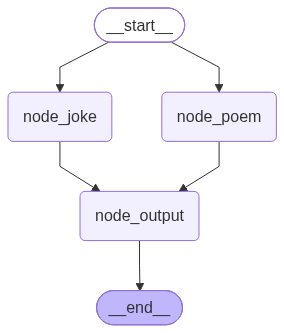

============================== -> 运行结果 <- ==============================
res: {} {'final_output': '关于 猫咪 的七言绝句：\n《咏猫》\n狸奴婉转戏帘栊，扑蝶寻香小院东。\n忽作凝神窥鼠穴，一身文锦藏弓中。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的七言句式，描绘了猫咪的灵动与机敏。首句“狸奴婉转戏帘栊”展现其嬉戏之态，次句“扑蝶寻香小院东”则进一步以扑蝶寻香的动作表现其活泼。后两句“忽作凝神窥鼠穴，一身文锦藏弓中”巧妙转换场景，由动入静，精准捕捉猫咪凝神窥视的瞬间，同时以“文锦藏弓”暗喻其捕猎本能，使得全诗既具画面感又富意趣。\n笑话：\n有一天，一只猫走进了一家酒吧，对吧台后面的酒保说：\n\n“给我来一杯牛奶。”\n\n酒保很惊讶：“我们这里不常招待猫，不过好吧，给你牛奶。”\n\n猫喝完了牛奶，满意地舔了舔爪子，然后说：“再来一杯。”\n\n酒保更好奇了，但还是给了它第二杯牛奶。猫又喝完了，舔了舔爪子，说：“再来一杯。”\n\n酒保忍不住问：“你喝这么多牛奶，不撑吗？”\n\n猫淡定地回答：“没事，我有九条命……而且我有九条命要用来上厕所。” 🐱🥛'}
============================== -> 历史检查点列表 <- ==============================
[StateSnapshot(values={'topic': '猫咪', 'poem': '《咏猫》\n狸奴婉转戏帘栊，扑蝶寻香小院东。\n忽作凝神窥鼠穴，一身文锦藏弓中。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的七言句式，描绘了猫咪的灵动与机敏。首句“狸奴婉转戏帘栊”展现其嬉戏之态，次句“扑蝶寻香小院东”则进一步以扑蝶寻香的动作表现其活泼。后两句“忽作凝神窥鼠穴，一身文锦藏弓中”巧妙转换场景，由动入静，精准捕捉猫咪凝神窥视的瞬间，同时以“文锦藏弓”暗喻其捕猎本能，使得全诗既具画面感又富意趣。', 'joke': '有一天，一只猫走进了一家酒吧，对吧台后面的酒保说：\n\n“给我来一杯牛奶。”\n\n酒保很惊讶：“我们这里不常招待猫，不过好吧，给你牛奶。”\n\n猫喝完了牛奶，满意地舔了舔爪子，然后说：“再来一杯。”\n\n酒保更

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from loguru import logger
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    final_output: str

class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    final_output: str

def node_poem(state: InputState) -> OverAllState:
    logger.info(f"node_poem 已执行")
    topic = state["topic"]
    poem = model.invoke([HumanMessage(f"写一首关于 {topic} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_joke(state: InputState) -> OverAllState:
    logger.info(f"node_joke 已执行")
    topic = state["topic"]
    joke = model.invoke([HumanMessage(f"写一个关于 {topic} 的笑话")]).content

    return {
        "joke": joke
    }

def node_output(state: OverAllState) -> OutputState:
    logger.info("node_output 已执行")
    topic = state["topic"]
    poem = state["poem"]
    joke = state["joke"]
    final_output = f"关于 {topic} 的七言绝句：\n{poem}\n笑话：\n{joke}"

    return {
        "final_output": final_output
    }

builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)
builder.add_node("node_poem", node_poem)
builder.add_node("node_joke", node_joke)
builder.add_node("node_output", node_output)

builder.add_edge(START, "node_poem")
builder.add_edge(START, "node_joke")
builder.add_edge("node_poem", "node_output")
builder.add_edge("node_joke", "node_output")
builder.add_edge("node_output", END)

checkpointer = InMemorySaver()
config = {"configurable": {"thread_id": "123"}}
graph = builder.compile(checkpointer=checkpointer)
res = graph.invoke({"topic": "猫咪"}, config=config)

from IPython.display import display
display(graph)

print('=' * 30, '-> 运行结果 <-', '=' * 30)
print("res: {}", res)

print('=' * 30, '-> 历史检查点列表 <-', '=' * 30)
history_checkpoints = list(graph.get_state_history(config=config))
print(history_checkpoints)

In [ ]:
============================== -> 运行结果 <- ==============================
res: {} {'final_output': '关于 猫咪 的七言绝句：\n《戏猫》\n狸奴酣卧小窗南，醉眼惺忪戏玉簪。\n忽跃雕檐追粉蝶，却衔明月入花龛。\n笑话：\n小猫问妈妈：“为什么人总说‘猫有九条命’？”  \n妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  \n小猫追问：“那为什么狗只有一条命？”  \n妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”'}
============================== -> 历史检查点列表 <- ==============================
[
    StateSnapshot(
        values={
            "topic": "猫咪",
            "poem": """
                        《戏猫》
                狸奴酣卧小窗南，醉眼惺忪戏玉簪。
                忽跃雕檐追粉蝶，却衔明月入花龛。
                """,
            "joke": """
                小猫问妈妈：“为什么人总说‘猫有九条命’？”  
                妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  
                小猫追问：“那为什么狗只有一条命？”  
                妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”
                """,
            "final_output": """
                关于 猫咪 的七言绝句：
                《戏猫》
                狸奴酣卧小窗南，醉眼惺忪戏玉簪。
                忽跃雕檐追粉蝶，却衔明月入花龛。
                笑话：
                小猫问妈妈：“为什么人总说‘猫有九条命’？”  
                妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  
                小猫追问：“那为什么狗只有一条命？”  
                妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”
                """
        },
        next=(),
        config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-4cc7-61bd-8002-bcd7f63c3238"
            }
        },
        metadata={
            "source": "loop",
            "step": 2,
            "parents": {}
        },
        created_at="2026-06-09T09:36:08.368575+00:00",
        parent_config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-4cc3-6d96-8001-8314b5dbbfe3"
            }
        },
        tasks=(),
        interrupts=()
    ),

    StateSnapshot(
        values={
            "topic": "猫咪",
            "poem": """
                        《戏猫》
                狸奴酣卧小窗南，醉眼惺忪戏玉簪。
                忽跃雕檐追粉蝶，却衔明月入花龛。
                """,
            "joke": """
                小猫问妈妈：“为什么人总说‘猫有九条命’？”  
                妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  
                小猫追问：“那为什么狗只有一条命？”  
                妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”
                """
        },
        next=("node_output",),
        config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-4cc3-6d96-8001-8314b5dbbfe3"
            }
        },
        metadata={
            "source": "loop",
            "step": 1,
            "parents": {}
        },
        created_at="2026-06-09T09:36:08.367236+00:00",
        parent_config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-393f-6082-8000-b9c0708bf03d"
            }
        },
        tasks=(
            PregelTask(
                id="91d81ad6-d2fb-ebd7-2dd1-8e08c2be5a07",
                name="node_output",
                path=("__pregel_pull", "node_output"),
                error=None,
                interrupts=(),
                state=None,
                result={
                    "final_output": """
                        关于 猫咪 的七言绝句：
                        《戏猫》
                        狸奴酣卧小窗南，醉眼惺忪戏玉簪。
                        忽跃雕檐追粉蝶，却衔明月入花龛。
                        笑话：
                        小猫问妈妈：“为什么人总说‘猫有九条命’？”  
                        妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  
                        小猫追问：“那为什么狗只有一条命？”  
                        妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”
                        """
                }
            ),
        ),
        interrupts=()
    ),

    StateSnapshot(
        values={
            "topic": "猫咪"
        },
        next=("node_poem", "node_joke"),
        config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-393f-6082-8000-b9c0708bf03d"
            }
        },
        metadata={
            "source": "loop",
            "step": 0,
            "parents": {}
        },
        created_at="2026-06-09T09:36:06.320542+00:00",
        parent_config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-393d-6b9a-bfff-180e30c1d3bc"
            }
        },
        tasks=(
            PregelTask(
                id="80d8974c-3450-6faa-8b06-dcf8787d74fc",
                name="node_poem",
                path=("__pregel_pull", "node_poem"),
                error=None,
                interrupts=(),
                state=None,
                result={
                    "poem": """
                            《戏猫》
                    狸奴酣卧小窗南，醉眼惺忪戏玉簪。
                    忽跃雕檐追粉蝶，却衔明月入花龛。
                    """
                }
            ),
            PregelTask(
                id="2ca46996-dfc6-6de3-3662-cf1fe41bf987",
                name="node_joke",
                path=("__pregel_pull", "node_joke"),
                error=None,
                interrupts=(),
                state=None,
                result={
                    "joke": """
                    小猫问妈妈：“为什么人总说‘猫有九条命’？”  
                    妈妈答：“因为人类怕我们死一次就够他们内疚一辈子。”  
                    小猫追问：“那为什么狗只有一条命？”  
                    妈妈叹气：“因为狗犯错靠装可怜，而我们靠记仇。”
                    """
                }
            ),
        ),
        interrupts=()
    ),

    StateSnapshot(
        values={},
        next=("__start__",),
        config={
            "configurable": {
                "thread_id": "123",
                "checkpoint_ns": "",
                "checkpoint_id": "1f163e6a-393d-6b9a-bfff-180e30c1d3bc"
            }
        },
        metadata={
            "source": "input",
            "step": -1,
            "parents": {}
        },
        created_at="2026-06-09T09:36:06.320009+00:00",
        parent_config=None,
        tasks=(
            PregelTask(
                id="3aa3bc58-3567-5832-d823-4373a9ab94e5",
                name="__start__",
                path=("__pregel_pull", "__start__"),
                error=None,
                interrupts=(),
                state=None,
                result={
                    "topic": "猫咪"
                }
            ),
        ),
        interrupts=()
    )
]

In [2]:
latest_history_checkpoint = graph.get_state(config=config)
print(latest_history_checkpoint)

StateSnapshot(values={'topic': '猫咪', 'poem': '《咏猫》\n狸奴婉转戏帘栊，扑蝶寻香小院东。\n忽作凝神窥鼠穴，一身文锦藏弓中。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的七言句式，描绘了猫咪的灵动与机敏。首句“狸奴婉转戏帘栊”展现其嬉戏之态，次句“扑蝶寻香小院东”则进一步以扑蝶寻香的动作表现其活泼。后两句“忽作凝神窥鼠穴，一身文锦藏弓中”巧妙转换场景，由动入静，精准捕捉猫咪凝神窥视的瞬间，同时以“文锦藏弓”暗喻其捕猎本能，使得全诗既具画面感又富意趣。', 'joke': '有一天，一只猫走进了一家酒吧，对吧台后面的酒保说：\n\n“给我来一杯牛奶。”\n\n酒保很惊讶：“我们这里不常招待猫，不过好吧，给你牛奶。”\n\n猫喝完了牛奶，满意地舔了舔爪子，然后说：“再来一杯。”\n\n酒保更好奇了，但还是给了它第二杯牛奶。猫又喝完了，舔了舔爪子，说：“再来一杯。”\n\n酒保忍不住问：“你喝这么多牛奶，不撑吗？”\n\n猫淡定地回答：“没事，我有九条命……而且我有九条命要用来上厕所。” 🐱🥛', 'final_output': '关于 猫咪 的七言绝句：\n《咏猫》\n狸奴婉转戏帘栊，扑蝶寻香小院东。\n忽作凝神窥鼠穴，一身文锦藏弓中。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的七言句式，描绘了猫咪的灵动与机敏。首句“狸奴婉转戏帘栊”展现其嬉戏之态，次句“扑蝶寻香小院东”则进一步以扑蝶寻香的动作表现其活泼。后两句“忽作凝神窥鼠穴，一身文锦藏弓中”巧妙转换场景，由动入静，精准捕捉猫咪凝神窥视的瞬间，同时以“文锦藏弓”暗喻其捕猎本能，使得全诗既具画面感又富意趣。\n笑话：\n有一天，一只猫走进了一家酒吧，对吧台后面的酒保说：\n\n“给我来一杯牛奶。”\n\n酒保很惊讶：“我们这里不常招待猫，不过好吧，给你牛奶。”\n\n猫喝完了牛奶，满意地舔了舔爪子，然后说：“再来一杯。”\n\n酒保更好奇了，但还是给了它第二杯牛奶。猫又喝完了，舔了舔爪子，说：“再来一杯。”\n\n酒保忍不住问：“你喝这么多牛奶，不撑吗？”\n\n猫淡定地回答：“没事，我有九条命……而且我有九条命要用来上厕所。” 🐱🥛'}, next=(), config={'configurable': {'thread_id': '123',

In [3]:
target_config = {
    "configurable": {
        "thread_id": "123",
        "checkpoint_id": "1f1b1d03-63e4-63ea-8000-73fb46082144"
    }
}

snapshot = graph.get_state(config=target_config)
print(snapshot)

StateSnapshot(values={'topic': '猫咪'}, next=('node_poem', 'node_joke'), config={'configurable': {'thread_id': '123', 'checkpoint_id': '1f1b1d03-63e4-63ea-8000-73fb46082144'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-16T13:12:04.656014+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b1d03-63e2-64f3-bfff-3b91f65b2565'}}, tasks=(PregelTask(id='7cc932d3-19a2-3764-46e5-6a9d7a910508', name='node_poem', path=('__pregel_pull', 'node_poem'), error=None, interrupts=(), state=None, result={'poem': '《咏猫》\n狸奴婉转戏帘栊，扑蝶寻香小院东。\n忽作凝神窥鼠穴，一身文锦藏弓中。\n\n赏析：这首作品以猫咪为主题，通过生动的意象和流畅的七言句式，描绘了猫咪的灵动与机敏。首句“狸奴婉转戏帘栊”展现其嬉戏之态，次句“扑蝶寻香小院东”则进一步以扑蝶寻香的动作表现其活泼。后两句“忽作凝神窥鼠穴，一身文锦藏弓中”巧妙转换场景，由动入静，精准捕捉猫咪凝神窥视的瞬间，同时以“文锦藏弓”暗喻其捕猎本能，使得全诗既具画面感又富意趣。'}), PregelTask(id='b5bd95d9-fba3-9683-f978-24bf28f5afba', name='node_joke', path=('__pregel_pull', 'node_joke'), error=None, interrupts=(), state=None, result={'joke': '有一天，一只猫走进了一家酒吧，对吧台后面的酒保说：\n\n“给我来一杯牛奶。